# Air Passengers：長期推移と季節性

## 計画・実行方針
run_id: `v020-exp-06`。Kaggleの指定公開データをSDKで検索し、対応するCSVだけを取得する。外部CSVミラーや外部スクリプトは使用しない。API取得・分析はJupyter MCPの実行セルだけで行う。API資格情報を表示しない。

1. 出典・取得時点・SHA-256を記録し、データ定義の確認度を区別する。
2. 月次連続性、欠損、重複、正の整数値を検査する。問題がなければ補間・外れ値除去をしない。
3. 月次折れ線と中心化12か月移動平均で長期推移を示し、年次集計で成長率を定量化する。
4. 年ごとの水準で正規化した月別季節指数、季節分解、年内変動幅で季節性と乗法性を調べる。
5. 部分期間・分解設定で感度を検査する。実質的な未解決点があれば追加依頼を原文で記録し、最大3回反復する。
6. 日本語の根拠付きInsight、予測上の限界、直接利用モジュール、改善候補を記録する。カーネル再起動後に全コードセルを上から実行し、visual_audit=Trueの監査とcompleted/failed状態を残す。

本ノートブックは記述的分析であり、因果効果や現在の航空需要を推定しない。12か月中心化移動平均は未来の観測も使うため予測入力には使わない。


In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, zipfile, warnings
from datetime import datetime, timezone
from dataclasses import asdict
import nbformat
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, ingestion, cleaning, eda, data_quality
from ai_data_scientist.language_router import detect_language
from ai_data_scientist.data_definition import FieldValue, build_manifest
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
from ai_data_scientist.visualization import render_chart, build_image_output
from ai_data_scientist.insight_engine import extract_cited_value, record_insight
from ai_data_scientist.notebook_audit import audit_notebook
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
handle = pm.resolve_project('kaggle-v020-kaggle-exp-06-flights')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
run_id = 'v020-exp-06'
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
@contextlib.contextmanager
def phase(name, write=False):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('実行の取消が要求されています')
    start = lifecycle.mark_write_start if write else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if write else lifecycle.mark_execution_end
    start(run_id)
    phase_log.append({'phase':name, 'event':'start', 'utc':datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(run_id)
        phase_log.append({'phase':name, 'event':'failed', 'error_type':type(exc).__name__})
        raise
    finally:
        end(run_id)
        phase_log.append({'phase':name, 'event':'end', 'utc':datetime.now(timezone.utc).isoformat()})
def show_json(value):
    display({'text/plain':json.dumps(value, ensure_ascii=False, indent=2, default=str)}, raw=True)
print({'run_id':run_id, 'language':detect_language('旅客数の長期推移と季節性を分析'), 'notebook':str(handle.notebook_path)})


{'run_id': 'v020-exp-06', 'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-06-flights/notebooks/kaggle-v020-kaggle-exp-06-flights.ipynb'}


## Kaggle取得・来歴

In [2]:
with phase('Kaggle API認証・公開データ検索・ファイル取得'):
    # SDKの標準出力と例外本文を非表示にし、資格情報が出力に混入しないようにする。
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            search_result = api.dataset_list(search='air passengers')
            matches = [item for item in search_result if str(item.ref) == 'rakannimer/air-passengers']
            if not matches:
                search_result = api.dataset_list(search='air-passengers', user='rakannimer')
                matches = [item for item in search_result if str(item.ref) == 'rakannimer/air-passengers']
            if not matches:
                raise LookupError('対応するKaggle公開データがAPI検索結果にない')
            slug = str(matches[0].ref)
            listing = api.dataset_list_files(slug)
            files = listing.files
            file_names = [str(item.name) for item in files]
            csv_names = [name for name in file_names if name.lower().endswith('.csv')]
            if len(csv_names) != 1:
                raise LookupError('CSVを一意に選べない')
            filename = csv_names[0]
            download_ok = api.dataset_download_file(slug, filename, path=str(data_dir), force=True, quiet=True)
        csv_path = data_dir / filename
        if not csv_path.exists():
            archive_path = data_dir / (filename + '.zip')
            if not archive_path.exists():
                raise FileNotFoundError('Kaggleから取得したファイルが存在しない')
            with zipfile.ZipFile(archive_path) as archive:
                matching = [name for name in archive.namelist() if Path(name).name == Path(filename).name]
                if len(matching) != 1:
                    raise LookupError('取得ZIP内の対応CSVを一意に選べない')
                csv_path.write_bytes(archive.read(matching[0]))
        provenance = {'owner_dataset_slug':slug, 'file_name':filename,
                      'retrieved_at_utc':datetime.now(timezone.utc).isoformat(),
                      'file_sha256':hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                      'source_url':'https://www.kaggle.com/datasets/' + slug,
                      'api_search':'air passengers', 'api_file_listing':file_names,
                      'csv_bytes':csv_path.stat().st_size, 'external_csv_mirror_used':False}
        original_sha = nbformat.read(handle.notebook_path, as_version=4).metadata.get('initial_provenance', {}).get('file_sha256')
        if original_sha and original_sha != provenance['file_sha256']:
            raise ValueError('Kaggle再取得ファイルのSHA-256が初回と異なるため再現性検証を停止')
        result = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=10000)
        raw = result.dataframe
        if result.truncated:
            raise ValueError('取得データが行数上限を超えたため停止')
    except Exception as exc:
        lifecycle.mark_failed(run_id)
        raise RuntimeError('Kaggle取得実験を停止: ' + type(exc).__name__ + '。外部ソースへはフォールバックしません。資格情報保護のためAPI例外本文は出力しません。') from None
    show_json(provenance)
    display(raw.head())
    print({'rows':len(raw), 'columns':list(raw.columns)})


{'rows': 144, 'columns': ['Month', '#Passengers']}


{
  "owner_dataset_slug": "rakannimer/air-passengers",
  "file_name": "AirPassengers.csv",
  "retrieved_at_utc": "2026-10-01T16:27:51.158655+00:00",
  "file_sha256": "5f8b316b84545d9cfb05612298df8415ce4c44421c7012d109465564b07ebc06",
  "source_url": "https://www.kaggle.com/datasets/rakannimer/air-passengers",
  "api_search": "air passengers",
  "api_file_listing": [
    "AirPassengers.csv"
  ],
  "csv_bytes": 1746,
  "external_csv_mirror_used": false
}

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## データ定義・分析前提manifest・意味的異常検査

In [3]:
with phase('データ定義・意味的品質・前処理'):
    public_meta = matches[0]
    public_description = str(getattr(public_meta, 'description', '') or '')
    public_title = str(getattr(public_meta, 'title', '') or '')
    show_json({'metadata_limit':'インストール済みKaggle SDKにdataset_viewがない（AttributeError）。検索結果メタデータだけを使用し、未確認の定義・単位は推定または不明として扱う。データ取得成功とは別のSDK固有制約。'})
    show_json({'kaggle_title':public_title, 'kaggle_description':public_description})
    if set(raw.columns) != {'Month', '#Passengers'}:
        raise ValueError('想定外の列定義')
    df = raw.rename(columns={'Month':'month', '#Passengers':'passengers'}).copy()
    df['month'] = pd.to_datetime(df['month'], format='%Y-%m', errors='raise')
    df['passengers'] = pd.to_numeric(df['passengers'], errors='raise')
    schema = {'month':{'not_null':True, 'unique':True},
              'passengers':{'not_null':True, 'min':1}}
    anomalies = data_quality.detect_anomalies(df, schema)
    expected_months = pd.date_range(df['month'].min(), df['month'].max(), freq='MS')
    continuity = df['month'].is_monotonic_increasing and df['month'].tolist() == expected_months.tolist()
    integer_positive = bool(np.isfinite(df['passengers']).all() and (df['passengers'] % 1 == 0).all())
    cleaning_report = cleaning.clean_dataset(df, operation='drop_duplicates')
    show_json({'semantic_anomalies':[asdict(item) for item in anomalies], 'monthly_continuity':continuity,
               'finite_integer_values':integer_positive, 'rows_before':cleaning_report.rows_before,
               'rows_after':cleaning_report.rows_after, 'rows_removed':cleaning_report.rows_removed,
               'columns_affected':cleaning_report.columns_affected})
    if anomalies or not continuity or not integer_positive or cleaning_report.rows_removed:
        raise ValueError('時系列品質検査に不合格。恣意的な補完・削除は行わない')
    df = cleaning_report.dataframe
    df['year'] = df['month'].dt.year
    df['month_number'] = df['month'].dt.month
    show_json(asdict(eda.explore(df)))
    FV = FieldValue
    definition_manifest = build_manifest(
        source={'dataset':FV(slug,'verified','Kaggle API検索'),
                'filename':FV(filename,'verified','dataset_list_files'),
                'sha256':FV(provenance['file_sha256'],'verified','取得CSVのSHA-256'),
                'measurement_pathway':FV(None,'unknown','Kaggle公開説明に収集経路なし')},
        dataset_scope={'period':FV([str(df.month.min().date()),str(df.month.max().date())],'verified','全144行'),
                       'frequency':FV('月次','verified','月初・欠落なしの検査'),
                       'population':FV('国際航空旅客','inferred','AirPassengersという名称と既知系列の文脈。CSVに母集団辞書なし'),
                       'geography':FV(None,'unknown','CSVに地理列なし')},
        variables={'month':{'definition':FV('観測年月','verified','Month列と年月形式の検査')},
                   'passengers':{'definition':FV('月別航空旅客の記録値','inferred','列名#Passengers'),
                                 'unit':FV('千人と推定。API公開説明・CSV内で単位未確認','inferred','値だけでは単位を特定できない'),
                                 'unique_persons_or_boardings':FV(None,'unknown','人数・搭乗回数の区別なし')}},
        transformations=('年月をdatetimeに変換','列名を正規化','重複削除検査:削除0','欠損補間なし','外れ値除去なし'))
    show_json({'data_definition_manifest':asdict(definition_manifest),
               'unresolved_unknown':[path for path,value in definition_manifest.unresolved_fields()],
               'inferred_caveats':['母集団','旅客数の定義','千人という単位']})
    assumptions = AnalysisAssumptionManifest(
        analysis_scope={'period':'1949–1960', 'target':'保存された月次旅客記録の記述', 'causal_claims':False},
        assumptions=(Assumption('monthly-complete','欠落・重複のない連続月次系列','verified',conclusion_critical=True),
                     Assumption('no-imputation','補間・異常値除去不要','verified',conclusion_critical=True),
                     Assumption('annual-normalization','年平均で除す季節指数は年内トレンドの影響を受け得る','assumed',
                                impact_if_false='季節指数の精密な値が変わる',conclusion_critical=True),
                     Assumption('future-regime','将来も同じ成長・季節構造','assumed',
                                impact_if_false='将来予測が破綻する',conclusion_critical=True)),
        causal_scope='descriptive',sampling=None)
    show_json({'analysis_assumption_manifest':asdict(assumptions),
               'check_manifest_findings':[asdict(item) for item in check_manifest(assumptions)]})
    show_json({'applicability':{'stats_analysis.correlation':'非定常水準間の相関は見せかけになりやすく本目的では使用しない',
                               'data_quality.validate_anomalies':'独立参照データ未提供。ミラー禁止のため未適用',
                               'dataset_validation.compare_datasets':'独立した第2データセット未提供のため未適用',
                               'anomaly_detection.detect_anomalies':'トレンド・季節性を無視した全期間z-scoreによる除去は不適切',
                               'mcp_gateway.run_and_record':'外部Jupyter MCPツールを直接利用。カーネル内から同じカーネルへ再入するPythonクライアントは提供されず、再入実行は避ける。実行はexecute_cell、ノートブック構成書込みはenqueue_writeを使用'}})


{
  "metadata_limit": "インストール済みKaggle SDKにdataset_viewがない（AttributeError）。検索結果メタデータだけを使用し、未確認の定義・単位は推定または不明として扱う。データ取得成功とは別のSDK固有制約。"
}

{
  "kaggle_title": "Air Passengers",
  "kaggle_description": ""
}

{
  "semantic_anomalies": [],
  "monthly_continuity": true,
  "finite_integer_values": true,
  "rows_before": 144,
  "rows_after": 144,
  "rows_removed": 0,
  "columns_affected": [
    "month",
    "passengers"
  ]
}

{
  "describe": {
    "month": {
      "count": 144,
      "mean": "1954-12-16 05:00:00",
      "min": "1949-01-01 00:00:00",
      "25%": "1951-12-24 06:00:00",
      "50%": "1954-12-16 12:00:00",
      "75%": "1957-12-08 18:00:00",
      "max": "1960-12-01 00:00:00",
      "std": NaN
    },
    "passengers": {
      "count": 144.0,
      "mean": 280.2986111111111,
      "min": 104.0,
      "25%": 180.0,
      "50%": 265.5,
      "75%": 360.5,
      "max": 622.0,
      "std": 119.9663169429432
    },
    "year": {
      "count": 144.0,
      "mean": 1954.5,
      "min": 1949.0,
      "25%": 1951.75,
      "50%": 1954.5,
      "75%": 1957.25,
      "max": 1960.0,
      "std": 3.4641016151377544
    },
    "month_number": {
      "count": 144.0,
      "mean": 6.5,
      "min": 1.0,
      "25%": 3.75,
      "50%": 6.5,
      "75%": 9.25,
      "max": 12.0,
      "std": 3.4641016151377544
    }
  },
  "dtypes": {
    "month": "datetime64[us]",
    "passengers": "int64",
    "year": "int32

{
  "data_definition_manifest": {
    "source": {
      "dataset": {
        "value": "rakannimer/air-passengers",
        "status": "verified",
        "source": "Kaggle API検索"
      },
      "filename": {
        "value": "AirPassengers.csv",
        "status": "verified",
        "source": "dataset_list_files"
      },
      "sha256": {
        "value": "5f8b316b84545d9cfb05612298df8415ce4c44421c7012d109465564b07ebc06",
        "status": "verified",
        "source": "取得CSVのSHA-256"
      },
      "measurement_pathway": {
        "value": null,
        "status": "unknown",
        "source": "Kaggle公開説明に収集経路なし"
      }
    },
    "dataset_scope": {
      "period": {
        "value": [
          "1949-01-01",
          "1960-12-01"
        ],
        "status": "verified",
        "source": "全144行"
      },
      "frequency": {
        "value": "月次",
        "status": "verified",
        "source": "月初・欠落なしの検査"
      },
      "population": {
        "value": "国際航空旅客",
        "status": "

{
  "analysis_assumption_manifest": {
    "analysis_scope": {
      "period": "1949–1960",
      "target": "保存された月次旅客記録の記述",
      "causal_claims": false
    },
    "assumptions": [
      {
        "id": "monthly-complete",
        "statement": "欠落・重複のない連続月次系列",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "no-imputation",
        "statement": "補間・異常値除去不要",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "annual-normalization",
        "statement": "年平均で除す季節指数は年内トレンドの影響を受け得る",
        "status": "assumed",
        "evidence_cell": null,
        "impact_if_false": "季節指数の精密な値が変わる",
        "conclusion_critical": true
      },
      {
        "id": "future-regime",
        "statement": "将来も同じ成長・季節構造",
        "status": "assumed",
        "evidence_cell": null,
    

{
  "applicability": {
    "stats_analysis.correlation": "非定常水準間の相関は見せかけになりやすく本目的では使用しない",
    "data_quality.validate_anomalies": "独立参照データ未提供。ミラー禁止のため未適用",
    "dataset_validation.compare_datasets": "独立した第2データセット未提供のため未適用",
    "anomaly_detection.detect_anomalies": "トレンド・季節性を無視した全期間z-scoreによる除去は不適切",
    "mcp_gateway.run_and_record": "外部Jupyter MCPツールを直接利用。カーネル内から同じカーネルへ再入するPythonクライアントは提供されず、再入実行は避ける。実行はexecute_cell、ノートブック構成書込みはenqueue_writeを使用"
  }
}

## 初回結果：長期推移・季節性・感度分析

年平均に対する月値の比で水準を除く。前半/後半と年平均/対数線形トレンド除去の6仕様を比較し、夏（7–8月）対冬（1–2・11–12月）の比の最大相対偏差が10%以下かを確認する。これは恣意的な異常値削除の感度ではなく、結論に関わる期間・トレンド定義の感度である。

In [4]:
with phase('初回分析:長期推移・季節性・乗法性・感度'):
    from statsmodels.tsa.seasonal import STL
    series = df.set_index('month')['passengers'].asfreq('MS').astype(float)
    annual = df.groupby('year')['passengers'].agg(['mean','sum','min','max'])
    annual['year_growth_pct'] = annual['mean'].pct_change()*100
    annual['range'] = annual['max'] - annual['min']
    annual['relative_range'] = annual['range']/annual['mean']
    annual['max_min_ratio'] = annual['max']/annual['min']
    df['year_mean'] = df.groupby('year')['passengers'].transform('mean')
    df['seasonal_index'] = df['passengers']/df['year_mean']
    seasonal_profile = df.groupby('month_number')['seasonal_index'].agg(['mean','min','max','std'])
    peak_months = df.loc[df.groupby('year')['passengers'].idxmax(), ['year','month_number','passengers']]
    trough_months = df.loc[df.groupby('year')['passengers'].idxmin(), ['year','month_number','passengers']]
    log_stl = STL(np.log(series),period=12,seasonal=13,robust=True).fit()
    log_remainder = pd.Series(log_stl.resid,index=series.index)
    season_strength = max(0,1-np.var(log_stl.resid)/np.var(log_stl.resid + log_stl.seasonal))
    growth_ratio = annual['mean'].iloc[-1]/annual['mean'].iloc[0]
    cagr = (growth_ratio**(1/(len(annual)-1))-1)*100
    summer_winter_ratio = df[df.month_number.isin([7,8])].seasonal_index.mean()/df[df.month_number.isin([1,2,11,12])].seasonal_index.mean()
    def contrast(subset, method):
        sub = df if subset=='all' else df[df.year.between(*( (1949,1954) if subset=='early' else (1955,1960) ))]
        if method=='annual_mean':
            values = sub.passengers/sub.groupby('year').passengers.transform('mean')
        else:
            t = np.arange(len(sub),dtype=float)
            log_fit = np.polyval(np.polyfit(t,np.log(sub.passengers),1),t)
            values = sub.passengers.to_numpy()/np.exp(log_fit)
        ratios = pd.Series(np.asarray(values),index=sub.index)
        return ratios[sub.month_number.isin([7,8])].mean()/ratios[sub.month_number.isin([1,2,11,12])].mean()
    sensitivity_plan = SensitivityPlan({'subset':['all','early','late'], 'method':['annual_mean','log_linear']}, max_runs=6)
    sensitivity_report = run_sensitivity(sensitivity_plan,contrast,stability_tolerance=0.10)
    initial_metrics = {'start_month':series.index.min().strftime('%Y-%m'), 'end_month':series.index.max().strftime('%Y-%m'),
                       'n_months':len(series), 'mean_1949':annual['mean'].iloc[0], 'mean_1960':annual['mean'].iloc[-1],
                       'annual_mean_ratio':growth_ratio,'annual_mean_increase_pct':(growth_ratio-1)*100,'annual_mean_cagr_pct':cagr,
                       'annual_total_1949':annual['sum'].iloc[0], 'annual_total_1960':annual['sum'].iloc[-1],
                       'all_years_annual_growth_positive':bool((annual.year_growth_pct.dropna()>0).all()),
                       'global_peak_month':series.idxmax().strftime('%Y-%m'),'global_peak_value':series.max(),
                       'global_min_month':series.idxmin().strftime('%Y-%m'),'global_min_value':series.min(),
                       'month_index_july':seasonal_profile.loc[7,'mean'],'month_index_august':seasonal_profile.loc[8,'mean'],
                       'month_index_november':seasonal_profile.loc[11,'mean'],
                       'summer_winter_ratio':summer_winter_ratio,'log_STL_season_strength':season_strength,
                       'absolute_range_1949':annual.loc[1949,'range'],'absolute_range_1960':annual.loc[1960,'range'],
                       'relative_range_1949':annual.loc[1949,'relative_range'],'relative_range_1960':annual.loc[1960,'relative_range'],
                       'sensitivity_stable':sensitivity_report.stable,
                       'sensitivity_max_relative_deviation':sensitivity_report.max_relative_deviation}
    show_json(initial_metrics)
    display(annual.round(4))
    display(seasonal_profile.round(4))
    display(peak_months)
    display(trough_months)
    show_json({'sensitivity_plan':asdict(sensitivity_plan),'sensitivity_report':asdict(sensitivity_report)})


{
  "start_month": "1949-01",
  "end_month": "1960-12",
  "n_months": 144,
  "mean_1949": 126.66666666666667,
  "mean_1960": 476.1666666666667,
  "annual_mean_ratio": 3.7592105263157896,
  "annual_mean_increase_pct": 275.92105263157896,
  "annual_mean_cagr_pct": 12.79283522401482,
  "annual_total_1949": "1520",
  "annual_total_1960": "5714",
  "all_years_annual_growth_positive": true,
  "global_peak_month": "1960-07",
  "global_peak_value": 622.0,
  "global_min_month": "1949-11",
  "global_min_value": 104.0,
  "month_index_july": 1.2363603060863473,
  "month_index_august": 1.23709544746581,
  "month_index_november": 0.831984911117928,
  "summer_winter_ratio": 1.4185933584685464,
  "log_STL_season_strength": 0.960014172220685,
  "absolute_range_1949": "44",
  "absolute_range_1960": "232",
  "relative_range_1949": 0.34736842105263155,
  "relative_range_1960": 0.4872243612180609,
  "sensitivity_stable": true,
  "sensitivity_max_relative_deviation": 0.05558545802120039
}

,mean,sum,min,max,year_growth_pct,range,relative_range,max_min_ratio
year,,,,,,,,
1949,126.6667,1520,104,148,NaN,44,0.3474,1.4231
1950,139.6667,1676,114,170,10.2632,56,0.4010,1.4912
1951,170.1667,2042,145,199,21.8377,54,0.3173,1.3724
1952,197.0000,2364,171,242,15.7689,71,0.3604,1.4152
1953,225.0000,2700,180,272,14.2132,92,0.4089,1.5111
1954,238.9167,2867,188,302,6.1852,114,0.4772,1.6064
1955,284.0000,3408,233,364,18.8699,131,0.4613,1.5622
1956,328.2500,3939,271,413,15.5810,142,0.4326,1.5240
1957,368.4167,4421,301,467,12.2366,166,0.4506,1.5515


,mean,min,max,std
month_number,,,,
1,0.8611,0.8234,0.8924,0.0190
2,0.8519,0.7869,0.9316,0.0472
3,0.9800,0.8799,1.0489,0.0502
4,0.9590,0.9134,1.0444,0.0385
5,0.9662,0.8950,1.0178,0.0339
6,1.1026,1.0460,1.1454,0.0324
7,1.2364,1.1675,1.3063,0.0536
8,1.2371,1.1684,1.3255,0.0482
9,1.0808,1.0533,1.1313,0.0212


,year,month_number,passengers
6,1949,7,148
18,1950,7,170
30,1951,7,199
43,1952,8,242
55,1953,8,272
66,1954,7,302
78,1955,7,364
90,1956,7,413
103,1957,8,467
115,1958,8,505


,year,month_number,passengers
10,1949,11,104
22,1950,11,114
24,1951,1,145
36,1952,1,171
58,1953,11,180
61,1954,2,188
73,1955,2,233
94,1956,11,271
97,1957,2,301
118,1958,11,310


{
  "sensitivity_plan": {
    "parameter_grid": {
      "subset": [
        "all",
        "early",
        "late"
      ],
      "method": [
        "annual_mean",
        "log_linear"
      ]
    },
    "max_runs": 6
  },
  "sensitivity_report": {
    "results": [
      {
        "specification": {
          "subset": "all",
          "method": "annual_mean"
        },
        "value": 1.4185933584685464
      },
      {
        "specification": {
          "subset": "all",
          "method": "log_linear"
        },
        "value": 1.4038339686137298
      },
      {
        "specification": {
          "subset": "early",
          "method": "annual_mean"
        },
        "value": 1.356239891151052
      },
      {
        "specification": {
          "subset": "early",
          "method": "log_linear"
        },
        "value": 1.3397401968922393
      },
      {
        "specification": {
          "subset": "late",
          "method": "annual_mean"
        },
        "value":

## 時系列に適した図表

月次推移は順序を保つ折れ線、長期傾向は中心化12か月移動平均、季節性は水準正規化した年別の季節プロファイル、乗法構造は対数STL分解で示す。移動平均の端部は窓不足により欠測であり、外挿しない。図中の単位は未確認である旨を明記する。

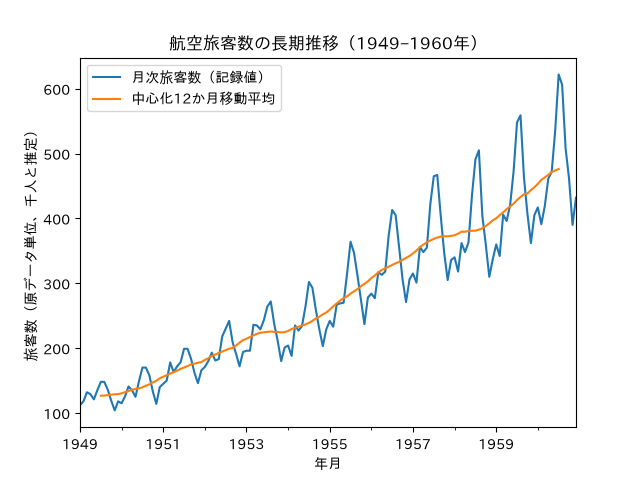

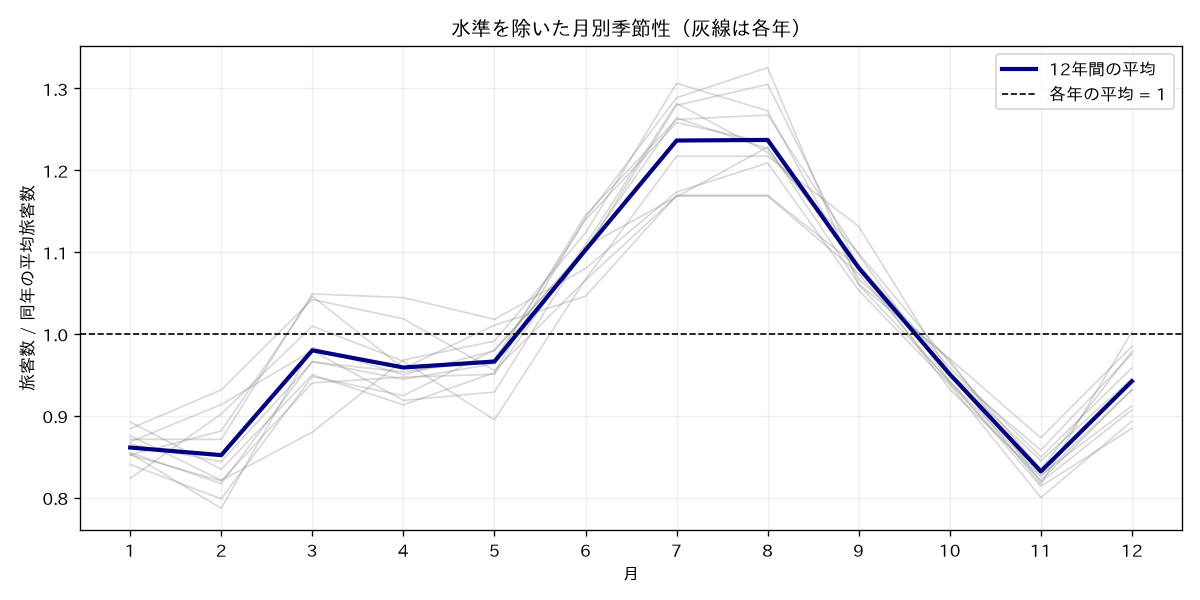

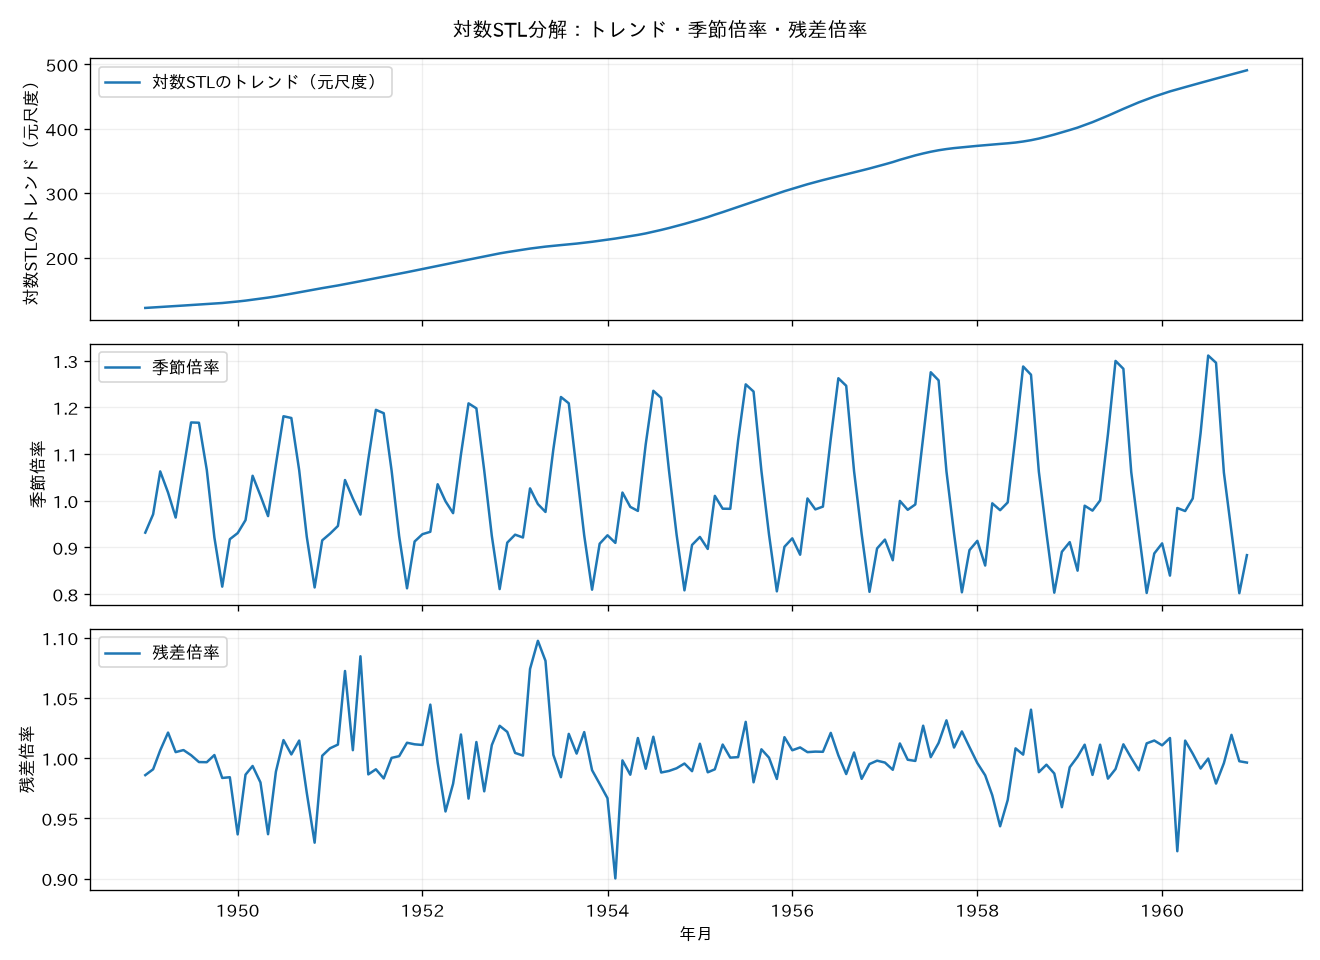

{
  "chart_specs": [
    {
      "metadata": {
        "title": "航空旅客数の長期推移（1949–1960年）",
        "xlabel": "年月",
        "ylabel": "旅客数（原データ単位、千人と推定）",
        "legend": [
          "月次旅客数（記録値）",
          "中心化12か月移動平均"
        ],
        "missing_glyphs": []
      },
      "bytes": 58321
    },
    {
      "metadata": {
        "title": "水準を除いた月別季節性（灰線は各年）",
        "xlabel": "月",
        "ylabel": "旅客数 / 同年の平均旅客数",
        "legend": [
          "12年間の平均",
          "各年の平均 = 1"
        ],
        "missing_glyphs": []
      },
      "bytes": 148628
    },
    {
      "metadata": {
        "title": "対数STL分解：トレンド・季節倍率・残差倍率",
        "xlabel": "年月",
        "ylabel": "各パネルの尺度",
        "legend": [
          "対数STLのトレンド（元尺度）",
          "季節倍率",
          "残差倍率"
        ],
        "missing_glyphs": []
      },
      "bytes": 164272
    }
  ],
  "visual_audit_policy": "missing_glyphsは実際の使用フォントのcharmapで検査。PNGを保存し、最終audit_notebook(visual_audit=True)でも監査。"
}

In [5]:
with phase('図表:月次推移・正規化季節性・対数分解'):
    import matplotlib.pyplot as plt
    from matplotlib import font_manager
    from matplotlib.ft2font import FT2Font
    import japanize_matplotlib
    japanize_matplotlib.japanize()
    charts = []
    def audit_labels(title,xlabel,ylabel,legend):
        chars = set(title+xlabel+ylabel+''.join(legend))
        font = FT2Font(font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family'])))
        return {'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,
                'missing_glyphs':[ord(ch) for ch in chars if not ch.isspace() and ord(ch) not in font.get_charmap()]}
    def emit(png, metadata):
        charts.append({'metadata':metadata,'bytes':len(png)})
        output = build_image_output(png)
        display(dict(output['data']),raw=True)
    trend_df = pd.DataFrame({'年月':series.index,'月次旅客数（記録値）':series.values,
                             '中心化12か月移動平均':series.rolling(12,center=True).mean().values})
    title,xlabel,ylabel = '航空旅客数の長期推移（1949–1960年）','年月','旅客数（原データ単位、千人と推定）'
    png = render_chart(trend_df,kind='line',x='年月',y=['月次旅客数（記録値）','中心化12か月移動平均'],
                       title=title,xlabel=xlabel,ylabel=ylabel)
    emit(png,audit_labels(title,xlabel,ylabel,['月次旅客数（記録値）','中心化12か月移動平均']))
    fig,ax = plt.subplots(figsize=(10,5))
    for year,sub in df.groupby('year'):
        ax.plot(sub.month_number,sub.seasonal_index,color='gray',alpha=.3,lw=1)
    ax.plot(seasonal_profile.index,seasonal_profile['mean'],color='navy',lw=2.5,label='12年間の平均')
    ax.axhline(1,color='black',ls='--',lw=1,label='各年の平均 = 1')
    title,xlabel,ylabel = '水準を除いた月別季節性（灰線は各年）','月','旅客数 / 同年の平均旅客数'
    ax.set(title=title,xlabel=xlabel,ylabel=ylabel,xticks=range(1,13))
    ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
    buffer = io.BytesIO(); fig.savefig(buffer,format='png',dpi=120); plt.close(fig)
    emit(buffer.getvalue(),audit_labels(title,xlabel,ylabel,['12年間の平均','各年の平均 = 1']))
    fig,axes = plt.subplots(3,1,figsize=(11,8),sharex=True)
    component_data = [np.exp(log_stl.trend), np.exp(log_stl.seasonal), np.exp(log_stl.resid)]
    component_names = ['対数STLのトレンド（元尺度）','季節倍率','残差倍率']
    for ax,values,name in zip(axes,component_data,component_names):
        ax.plot(series.index,values,label=name); ax.set_ylabel(name); ax.legend(loc='upper left'); ax.grid(alpha=.2)
    axes[-1].set_xlabel('年月'); fig.suptitle('対数STL分解：トレンド・季節倍率・残差倍率'); fig.tight_layout()
    buffer = io.BytesIO(); fig.savefig(buffer,format='png',dpi=120); plt.close(fig)
    emit(buffer.getvalue(),audit_labels('対数STL分解：トレンド・季節倍率・残差倍率','年月','各パネルの尺度',component_names))
    show_json({'chart_specs':charts,'visual_audit_policy':'missing_glyphsは実際の使用フォントのcharmapで検査。PNGを保存し、最終audit_notebook(visual_audit=True)でも監査。'})


Insight：1949年から1960年までの年平均旅客記録は約3.76倍になった。年平均ベースの年率換算は約12.79%だが、将来の成長率ではない。

```evidence
{"execution_count":4,"cited_value":"3.7592105263157896","claim_type":"descriptive"}
```

Insight：年平均で水準を除いた夏（7–8月）の指数は冬（1–2・11–12月）の約1.42倍。単純な月次水準比較ではなく、各年の平均で正規化した結果である。

```evidence
{"execution_count":4,"cited_value":"1.4185933584685464","claim_type":"descriptive"}
```

Insight：初回6仕様の夏冬比の最大相対偏差は約5.56%で、事前に定めた10%許容以内。ただし固定した季節振幅を保証するものではない。

```evidence
{"execution_count":4,"cited_value":"0.05558545802120039","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復1：自然言語の追加依頼（原文）

初回結果では年平均で正規化しても季節振幅が後半ほど大きく見えます。前半と後半の夏冬比を、対数STLの季節窓と頑健推定の有無を変えて比較し、月の日数で割った場合も確認してください。7月と8月の順位を断定できるか、季節性は強いが固定の季節倍率ではないのかを根拠付きで説明してください。

選定理由：全期間の平均的な夏冬比だけでは、相対振幅の変化と月日数の影響を除外できない。結論を「季節性は一定」と誤解させないために実行する。

In [6]:
with phase('反復1:季節構造の変化・月日数・分解感度'):
    annual_daily = df.assign(per_day=df.passengers/df.month.dt.days_in_month)
    annual_daily['daily_index'] = annual_daily.per_day/annual_daily.groupby('year').per_day.transform('mean')
    daily_profile = annual_daily.groupby('month_number').daily_index.mean()
    def stl_contrast(seasonal, robust, segment):
        fit = STL(np.log(series),period=12,seasonal=seasonal,robust=robust).fit()
        seasonal_multiplier = pd.Series(np.exp(fit.seasonal),index=series.index)
        selected = seasonal_multiplier if segment=='all' else seasonal_multiplier[
            seasonal_multiplier.index.year <=1954 if segment=='early' else seasonal_multiplier.index.year >=1955]
        return selected[selected.index.month.isin([7,8])].mean()/selected[selected.index.month.isin([1,2,11,12])].mean()
    stl_plan = SensitivityPlan({'seasonal':[13,7,25],'robust':[True,False],'segment':['all','early','late']},max_runs=18)
    stl_sensitivity = run_sensitivity(stl_plan,stl_contrast,stability_tolerance=.10)
    stl_table = pd.DataFrame([{**item.specification,'summer_winter_ratio':item.value} for item in stl_sensitivity.results])
    stl_wide = stl_table.pivot(index=['seasonal','robust'],columns='segment',values='summer_winter_ratio')
    stl_wide['late_minus_early'] = stl_wide.late-stl_wide.early
    # 年ごとの比率は12観測しかない。通常の独立標本検定は使わず記述的な比較とする。
    yearly_contrast = df.groupby('year').apply(
        lambda sub:sub.loc[sub.month_number.isin([7,8]),'passengers'].mean()/
                   sub.loc[sub.month_number.isin([1,2,11,12]),'passengers'].mean(),include_groups=False)
    daily_ratio = annual_daily.loc[annual_daily.month_number.isin([7,8]),'daily_index'].mean()/annual_daily.loc[annual_daily.month_number.isin([1,2,11,12]),'daily_index'].mean()
    early_ratio = yearly_contrast.loc[1949:1954].mean()
    late_ratio = yearly_contrast.loc[1955:1960].mean()
    iteration1_metrics = {'yearwise_summer_winter_early_mean':early_ratio,
                          'yearwise_summer_winter_late_mean':late_ratio,
                          'late_vs_early_relative_increase_pct':(late_ratio/early_ratio-1)*100,
                          'daily_adjusted_summer_winter_ratio':daily_ratio,
                          'all_STL_specs_late_greater_than_early':bool((stl_wide.late_minus_early>0).all()),
                          'STL_min_late_minus_early':stl_wide.late_minus_early.min(),
                          'STL_sensitivity_stable':stl_sensitivity.stable,
                          'STL_sensitivity_max_relative_deviation':stl_sensitivity.max_relative_deviation,
                          'july_august_mean_index_difference':seasonal_profile.loc[8,'mean']-seasonal_profile.loc[7,'mean'],
                          'years_July_exceeds_August':int((df[df.month_number==7].passengers.to_numpy()>df[df.month_number==8].passengers.to_numpy()).sum()),
                          'years_August_exceeds_July':int((df[df.month_number==8].passengers.to_numpy()>df[df.month_number==7].passengers.to_numpy()).sum()),
                          'years_July_equals_August':int((df[df.month_number==7].passengers.to_numpy()==df[df.month_number==8].passengers.to_numpy()).sum())}
    show_json(iteration1_metrics)
    display(stl_wide)
    display(pd.DataFrame({'月次総量の指数':seasonal_profile['mean'],'日数調整の指数':daily_profile}))
    show_json({'sensitivity_plan':asdict(stl_plan),'sensitivity_report':asdict(stl_sensitivity)})
    assumptions = AnalysisAssumptionManifest(analysis_scope=assumptions.analysis_scope,
        assumptions=tuple(Assumption(a.id,a.statement,'tested' if a.id=='annual-normalization' else a.status,
                                     impact_if_false=a.impact_if_false,conclusion_critical=a.conclusion_critical)
                          for a in assumptions.assumptions),causal_scope='descriptive')
    show_json({'updated_assumption_manifest':asdict(assumptions),'remaining_findings':[asdict(item) for item in check_manifest(assumptions)],
               'iteration_selection':'全期間の夏冬比が安定していても、前半と後半の差・日数効果・7月8月の微小差は未解決だった',
               'remaining_limits':'12年のみ。STLは全期間を用いた記述的平滑化であり独立な検証ではない。日数調整は月次総量とは別の指標。季節変化の原因は特定できない。'})


{
  "yearwise_summer_winter_early_mean": 1.357069268948818,
  "yearwise_summer_winter_late_mean": 1.4828670382011904,
  "late_vs_early_relative_increase_pct": 9.269811949231975,
  "daily_adjusted_summer_winter_ratio": 1.3749361036604713,
  "all_STL_specs_late_greater_than_early": true,
  "STL_min_late_minus_early": 0.12386435557612252,
  "STL_sensitivity_stable": true,
  "STL_sensitivity_max_relative_deviation": 0.0521452026344324,
  "july_august_mean_index_difference": 0.0007351413794627337,
  "years_July_exceeds_August": 4,
  "years_August_exceeds_July": 5,
  "years_July_equals_August": 3
}

segment               all     early      late  late_minus_early
seasonal robust                                                
7        False   1.405559  1.342630  1.470030          0.127400
         True    1.396464  1.330466  1.464612          0.134146
13       False   1.405403  1.343066  1.469269          0.126203
         True    1.397174  1.333300  1.463126          0.129826
25       False   1.405464  1.344264  1.468129          0.123864
         True    1.397713  1.334729  1.462683          0.127954

,月次総量の指数,日数調整の指数
month_number,,
1,0.861134,0.845945
2,0.851871,0.918415
3,0.979998,0.962671
4,0.958966,0.973432
5,0.966231,0.949184
6,1.102620,1.119292
7,1.236360,1.214566
8,1.237095,1.215285
9,1.080781,1.097094


{
  "sensitivity_plan": {
    "parameter_grid": {
      "seasonal": [
        13,
        7,
        25
      ],
      "robust": [
        true,
        false
      ],
      "segment": [
        "all",
        "early",
        "late"
      ]
    },
    "max_runs": 18
  },
  "sensitivity_report": {
    "results": [
      {
        "specification": {
          "seasonal": 13,
          "robust": true,
          "segment": "all"
        },
        "value": 1.3971742701924352
      },
      {
        "specification": {
          "seasonal": 13,
          "robust": true,
          "segment": "early"
        },
        "value": 1.3333000202240681
      },
      {
        "specification": {
          "seasonal": 13,
          "robust": true,
          "segment": "late"
        },
        "value": 1.4631263564720316
      },
      {
        "specification": {
          "seasonal": 13,
          "robust": false,
          "segment": "all"
        },
        "value": 1.405403061702705
      },
 

{
  "updated_assumption_manifest": {
    "analysis_scope": {
      "period": "1949–1960",
      "target": "保存された月次旅客記録の記述",
      "causal_claims": false
    },
    "assumptions": [
      {
        "id": "monthly-complete",
        "statement": "欠落・重複のない連続月次系列",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "no-imputation",
        "statement": "補間・異常値除去不要",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "annual-normalization",
        "statement": "年平均で除す季節指数は年内トレンドの影響を受け得る",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": "季節指数の精密な値が変わる",
        "conclusion_critical": true
      },
      {
        "id": "future-regime",
        "statement": "将来も同じ成長・季節構造",
        "status": "assumed",
        "evidence_cell": null,
      

Insight：年ごとの夏冬比の平均は前半約1.357から後半約1.483に上昇し、相対増加は約9.27%。対数STLの全6設定でも後半の比が大きく、季節性は強いが季節倍率は完全には固定されていない。

```evidence
{"execution_count":6,"cited_value":"9.269811949231975","claim_type":"descriptive"}
```

Insight：月日数を除いた日平均でも夏冬比は約1.375であり、夏の高さは31日という月長だけでは説明できない。ただし日平均は月次総量とは異なる指標。

```evidence
{"execution_count":6,"cited_value":"1.3749361036604713","claim_type":"descriptive"}
```

Insight：7月と8月の平均季節指数差は約0.000735だけ。年別には7月優位4年・8月優位5年・同数3年で、頂点を一方の月だけに断定せず「7–8月の夏季ピーク」とする。

```evidence
{"execution_count":6,"cited_value":"0.0007351413794627337","claim_type":"descriptive"}
```

## 反復依頼履歴（続き）

### 反復2：自然言語の追加依頼（原文）

季節性は明瞭ですが相対振幅は変化しており、12.79%という過去の年率成長をそのまま予測に使えるかが未解決です。過去のデータだけを学習に使う時系列のローリング起点検証で、季節ナイーブ、対数線形トレンド＋月効果、対数Holt-Wintersを12か月先と24か月先で比較してください。モデル・起点・予測期間に対する誤差の感度を記録し、この短い歴史データから将来予測について何が言え、何は言えないかを説明してください。

選定理由：過去の成長率と良好な季節分解だけでは将来の精度を評価できない。学習と検証の時間順序を守り、予測上の限界を実測誤差で補強する。

{
  "validation_rows": 18,
  "train_only_no_future_leakage": true,
  "test_range": "1955–1960（起点1954・1956・1958年末）",
  "best_model_average_MAPE": "log_holt_winters",
  "MAPE_min_pct": 2.7689972193096297,
  "MAPE_max_pct": 21.524036219930966,
  "forecast_error_sensitivity_stable": false,
  "forecast_error_max_relative_deviation": 3.2425298628832353,
  "HW_MAPE_h12_pct": 4.784435017088408,
  "HW_MAPE_h24_pct": 6.2004392250047715,
  "naive_MAPE_h12_pct": 12.553166988027456,
  "naive_MAPE_h24_pct": 16.40100086288599
}

,origin_year,horizon_months,model,MAE,MAPE_pct,seasonal_MASE,bias_pct
0,1954,12,seasonal_naive,45.0833,15.8429,1.9587,-15.8429
1,1954,12,log_linear_month,8.8063,3.1271,0.3826,0.9862
2,1954,12,log_holt_winters,15.1874,5.0734,0.6598,-4.0692
3,1954,24,seasonal_naive,67.2083,21.5240,2.9200,-21.5240
4,1954,24,log_linear_month,9.0145,2.9089,0.3917,0.4707
5,1954,24,log_holt_winters,18.5547,5.7179,0.8061,-5.2158
6,1956,12,seasonal_naive,40.1667,10.7586,1.3755,-10.7586
7,1956,12,log_linear_month,12.0949,3.3743,0.4142,1.7967
8,1956,12,log_holt_winters,10.8446,2.7690,0.3714,-0.4347
9,1956,24,seasonal_naive,46.4583,12.1556,1.5909,-12.1556


MAE  MAPE_pct  seasonal_MASE  bias_pct
model            horizon_months                                            
log_holt_winters 12              18.5421    4.7844         0.6890   -3.6570
                 24              24.3189    6.2004         0.8977   -2.2630
log_linear_month 12              18.7565    5.0773         0.6782    3.8378
                 24              27.0564    6.9900         0.9650    5.9144
seasonal_naive   12              44.1944   12.5532         1.6636  -12.5532
                 24              61.6389   16.4010         2.3348  -16.4010

{
  "sensitivity_plan": {
    "parameter_grid": {
      "model": [
        "log_holt_winters",
        "log_linear_month",
        "seasonal_naive"
      ],
      "origin": [
        1954,
        1956,
        1958
      ],
      "horizon": [
        12,
        24
      ]
    },
    "max_runs": 18
  },
  "sensitivity_report": {
    "results": [
      {
        "specification": {
          "model": "log_holt_winters",
          "origin": 1954,
          "horizon": 12
        },
        "value": 5.073396514716144
      },
      {
        "specification": {
          "model": "log_holt_winters",
          "origin": 1954,
          "horizon": 24
        },
        "value": 5.7179260172578665
      },
      {
        "specification": {
          "model": "log_holt_winters",
          "origin": 1956,
          "horizon": 12
        },
        "value": 2.7689972193096297
      },
      {
        "specification": {
          "model": "log_holt_winters",
          "origin": 1956,
          "h

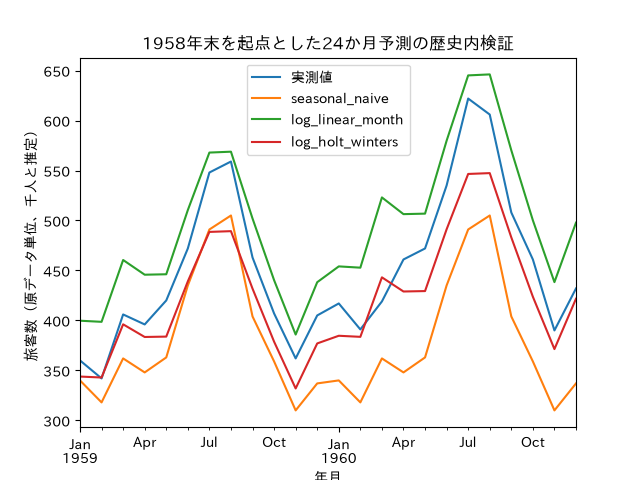

In [7]:
with phase('反復2:時系列ローリング起点の予測限界検証'):
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    forecast_rows = []
    forecast_predictions = {}
    forecast_warnings = []
    models = ['seasonal_naive','log_linear_month','log_holt_winters']
    def make_forecast(train, horizon, model):
        if model=='seasonal_naive':
            return np.tile(train.iloc[-12:].to_numpy(),int(np.ceil(horizon/12)))[:horizon]
        if model=='log_linear_month':
            train_t = np.arange(len(train),dtype=float)
            future_t = np.arange(len(train),len(train)+horizon,dtype=float)
            def design(t):
                month = (t.astype(int)%12)+1
                return np.column_stack([np.ones(len(t)),t]+[(month==m).astype(float) for m in range(2,13)])
            coef = np.linalg.lstsq(design(train_t),np.log(train.to_numpy()),rcond=None)[0]
            return np.exp(design(future_t)@coef)
        with warnings.catch_warnings(record=True) as recorded:
            warnings.simplefilter('always')
            fitted = ExponentialSmoothing(np.log(train),trend='add',seasonal='add',
                                          seasonal_periods=12,initialization_method='estimated').fit(optimized=True)
        forecast_warnings.extend({'model':model,'train_end':str(train.index[-1].date()),
                                  'warning_category':type(w.message).__name__, 'message':str(w.message)} for w in recorded)
        if any(type(w.message).__name__=='ConvergenceWarning' for w in recorded):
            raise RuntimeError('Holt-Wintersが収束しないため予測検証を停止')
        return np.exp(np.asarray(fitted.forecast(horizon)))
    for origin in [1954,1956,1958]:
        train = series[series.index.year<=origin]
        for horizon in [12,24]:
            test = series[series.index>train.index[-1]].iloc[:horizon]
            if len(test)!=horizon:
                raise ValueError('検証期間不足')
            train_scale = np.mean(np.abs(train.to_numpy()[12:]-train.to_numpy()[:-12]))
            for model in models:
                predicted = make_forecast(train,horizon,model)
                if not np.isfinite(predicted).all() or not (predicted>0).all():
                    raise ValueError('予測が有限正値でない')
                error = predicted-test.to_numpy()
                forecast_rows.append({'origin_year':origin,'horizon_months':horizon,'model':model,
                                      'MAE':float(np.mean(np.abs(error))),
                                      'MAPE_pct':float(100*np.mean(np.abs(error)/test.to_numpy())),
                                      'seasonal_MASE':float(np.mean(np.abs(error))/train_scale),
                                      'bias_pct':float(100*np.mean(error/test.to_numpy()))})
                forecast_predictions[(origin,horizon,model)] = pd.Series(predicted,index=test.index)
    forecast_results = pd.DataFrame(forecast_rows)
    validation_summary = forecast_results.groupby(['model','horizon_months'])[['MAE','MAPE_pct','seasonal_MASE','bias_pct']].mean()
    def forecast_error(model, origin, horizon):
        return forecast_results.loc[(forecast_results.model==model)&(forecast_results.origin_year==origin)&
                                    (forecast_results.horizon_months==horizon),'MAPE_pct'].item()
    forecast_plan = SensitivityPlan({'model':['log_holt_winters','log_linear_month','seasonal_naive'],
                                    'origin':[1954,1956,1958],'horizon':[12,24]},max_runs=18)
    forecast_sensitivity = run_sensitivity(forecast_plan,forecast_error,stability_tolerance=.20)
    iteration2_metrics = {'validation_rows':len(forecast_results), 'train_only_no_future_leakage':True,
                          'test_range':'1955–1960（起点1954・1956・1958年末）',
                          'best_model_average_MAPE':forecast_results.groupby('model').MAPE_pct.mean().idxmin(),
                          'MAPE_min_pct':forecast_results.MAPE_pct.min(), 'MAPE_max_pct':forecast_results.MAPE_pct.max(),
                          'forecast_error_sensitivity_stable':forecast_sensitivity.stable,
                          'forecast_error_max_relative_deviation':forecast_sensitivity.max_relative_deviation,
                          'HW_MAPE_h12_pct':validation_summary.loc[('log_holt_winters',12),'MAPE_pct'],
                          'HW_MAPE_h24_pct':validation_summary.loc[('log_holt_winters',24),'MAPE_pct'],
                          'naive_MAPE_h12_pct':validation_summary.loc[('seasonal_naive',12),'MAPE_pct'],
                          'naive_MAPE_h24_pct':validation_summary.loc[('seasonal_naive',24),'MAPE_pct']}
    show_json(iteration2_metrics)
    display(forecast_results.round(4))
    display(validation_summary.round(4))
    show_json({'sensitivity_plan':asdict(forecast_plan), 'sensitivity_report':asdict(forecast_sensitivity),
               'fit_warnings':forecast_warnings,
               'iteration_selection':'未来の構造継続という未検証の前提と、記述的な分解のよい適合を予測性能と取り違えるリスクを評価',
               'remaining_limits':'各予測期間3起点のみ。12/24か月検証は一部同じ観測を使うため18行は独立反復ではない。対数予測の単純逆変換は中央値相当で平均のバイアス補正なし。モデル選択も同じ歴史内の比較であり外部検証や予測区間の較正ではない。1961年以後や現代への外挿を保証しない。'})
    forecast_chart = pd.DataFrame({'年月':series.loc['1959-01':'1960-12'].index,
                                   '実測値':series.loc['1959-01':'1960-12'].values})
    for model in models:
        forecast_chart[model] = forecast_predictions[(1958,24,model)].values
    title,xlabel,ylabel = '1958年末を起点とした24か月予測の歴史内検証','年月','旅客数（原データ単位、千人と推定）'
    png = render_chart(forecast_chart,kind='line',x='年月',y=['実測値']+models,title=title,xlabel=xlabel,ylabel=ylabel)
    forecast_chart_metadata = audit_labels(title,xlabel,ylabel,['実測値']+models)
    emit(png,forecast_chart_metadata)


Insight：3起点の歴史内検証で対数Holt-Wintersの平均MAPEは12か月約4.78%、24か月約6.20%。単純な前年同月維持より小さいが、将来や現代の精度は保証しない。

```evidence
{"execution_count":7,"cited_value":"4.784435017088408","claim_type":"descriptive"}
```

Insight：モデル・起点・予測期間18仕様でMAPEは約2.77–21.52%に広がり、20%許容の感度判定はstable=False。最大相対偏差約324.25%は最初の仕様を基準にした量で、すべての条件で一定の予測精度があるとは言えない。

```evidence
{"execution_count":7,"cited_value":"3.2425298628832353","claim_type":"descriptive"}
```

## 結果の解釈・データ期間・予測上の限界

対象は**1949年1月から1960年12月までの144か月、12年**である。記録値の月平均は126.67から476.17へ増加し、長期的な増加と毎年7–8月に高い季節性が同時にある。月次の上下を長期停滞と読み違えない。11月の正規化指数は約0.832、7–8月は約1.237。ただし年内の日数とトレンドを除いても後半の相対季節振幅は大きく、完全に一定の季節倍率とは言えない。

千人という単位と国際旅客という母集団は**推定**であり、取得できたAPI説明とCSVには検証できる辞書がない。絶対数を確定した「人数」として主張せず、原データの記録値と無次元の比を中心に解釈する。人数か搭乗回数か、地域、収集方法も不明。SHA-256が一致することはファイル同一性の検証であり、意味の検証ではない。

過去の年平均の年率換算約12.79%を将来へ機械的に延長しない。歴史内の3起点検証では対数Holt-Wintersの平均MAPEが12か月約4.78%、24か月約6.20%だったが、起点・期間・モデルにより誤差は変わる。これは1961年以後や現在の精度ではない。12/24か月の検証区間は重なるため18評価を独立標本とみなせず、ここで選んだモデルに独立した最終テスト期間もない。外生要因、制度・供給・路線・景気の変化、突発ショックを説明できず、予測区間の較正もしていない。因果的な理由の特定や現在の航空需要への外挿はしない。

## 反復終了の判断

反復1は正規化・月長・季節変化・ピーク月の曖昧さを解決し、反復2は歴史内の実測予測誤差を追加した。残る定義の確認と将来の構造変化は同じCSVを再加工しても解消できない。結論に価値ある追加分析がなくなったため**2回で終了**し、上限3回を埋めるためだけの反復はしない。各反復の原文、選定理由、結果、実行出力、根拠manifest、残る限界は前の節に記録済み。


## 使用したJupytermindモジュール

以下はノートブックまたはJupyter MCPの構成セルから**直接importして呼び出した**ものだけである。間接利用を使用済みに数えない。

| モジュール | 直接呼び出した関数・クラス・メソッド | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 指定ルートのslug検証、Notebookと取得ファイルの配置、構成・根拠・監査記録を単一書込み経路で保存 |
| `ai_data_scientist.language_router` | `detect_language` | 日本語の依頼を識別 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start`, `mark_execution_end`, `mark_write_start`, `mark_write_end`, `is_cancel_requested`, `mark_completed`, `mark_failed`, `get_run_status`, `wait_for_quiescence` | 長時間処理前の登録、実行/書込みの記録、取消確認、完了/失敗と静止確認 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | Kaggle SDKから取得したローカルCSVを行数上限付きで読込 |
| `ai_data_scientist.cleaning` | `clean_dataset` | 重複削除の必要性と行/列への影響を報告（削除0） |
| `ai_data_scientist.eda` | `explore` | 型・欠損・要約統計を記録 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 非欠損・正値・月キーの一意性という意味的制約を検査 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 出典と定義のverified/inferred/unknownを分離。manifest型はbuild_manifest戻り値のメソッドとして直接利用 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 記述的範囲、正規化の感度、将来構造継続の未検証リスクを記録 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 6仕様の正規化比較、18仕様のSTL比較、18仕様の予測誤差比較 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 時系列折れ線の描画、独自の季節プロファイル/分解図をPNGのMIME bundleとして出力 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 実行済みセルの実際のtext/plain出力から数値を抽出し、根拠manifestを付ける |
| `ai_data_scientist.notebook_audit` | `audit_notebook`, `audit_visual_outputs` | Notebook実行・根拠・visual_audit=Trueの監査と改善候補の局所再現 |

`mcp_gateway`, `stats_analysis`, `anomaly_detection`, `dataset_validation`は直接import/呼出ししていない。未適用理由はデータ定義セルのapplicabilityに記録。外部Jupyter MCPツールで実行し、enqueue_writeでNotebookの構成・根拠を保存した。外部描画のためのPython実行経路や同じカーネルへの再入を作らない。

外部ライブラリ（Jupytermindとは区別）：KaggleApiのauthenticate/dataset_list/dataset_list_files/dataset_download_file、pandas、NumPy、statsmodelsのSTLとExponentialSmoothing、matplotlib、japanize_matplotlib、nbformat、IPython.display。計画・反復の構成にもJupyter MCPのみを使い、subprocess・外部スクリプト・端末コマンド・作業エージェントは使用しない。


## Jupytermind改善候補

### VIZ-AUDIT-01：監査メタデータ未提供を検出しない機能不足

- **分類**：Jupytermindの図表監査の検査不足（本分析の結論・実測値に影響なし）。
- **再現条件**：実在するPNG出力を持つcode cellに`metadata.chart`を付けず、`notebook_audit.audit_visual_outputs(notebook, (0,))`を直接呼び出す。下の再現セルで実行。
- **期待する挙動**：字形、タイトル、軸ラベル、凡例について未確認/未提供の警告が出る。
- **実際の挙動**：PNGはあるがchartメタデータが空でもfindingsは空。出力のactual_findingsとmissing_metadata_passes_without_findingsを参照。
- **影響**：メタデータなしの図表が監査済みと誤解され得る。画像からラベルを読み取っているわけではない。
- **回避策**：本Notebookでは実際の描画フォントcharmapでmissing_glyphsを検査し、title/xlabel/ylabel/legendをすべて明示してchart metadataへ保存。最終visual_audit=Trueに加え、図を目視して線・ラベル・凡例の可読性を確認。
- **関係するセルとログ**：「時系列に適した図表」のchart_specs、「反復2」の予測図、直後のimprovement_reproduction出力。最終監査のchart_metadata_manifestとvisual_findingsにも記録。

### 切り分け：Jupytermindの改善候補ではない事象

Kaggle SDKには`dataset_view`がなく初回の任意メタデータ取得がAttributeErrorで失敗した。指定データの検索・ファイル取得は成功しており、検索結果メタデータに戻し、空の説明から単位を確定しない。API例外本文や資格情報は表示しなかった。関係ログはデータ定義セルのmetadata_limit、再現セルのSDK_separation。Jupyter MCPは未作成の親ディレクトリにcreateできなかったため、構成用Notebookからproject_manager.ensure_notebookで指定先を作成した。これはMCP操作の前提条件であり分析モジュールの不具合とは扱わない。Copilot CLI・ベンチマークランナー固有の分析上の問題は観測していない。


In [8]:
with phase('直接利用モジュール・改善候補の再現確認・最終前提'):
    from ai_data_scientist.notebook_audit import audit_visual_outputs
    repro = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('再現用の実在PNG',outputs=[build_image_output(png)],execution_count=1)])
    missing_metadata_findings = audit_visual_outputs(repro,(0,))
    show_json({'improvement_reproduction':{'case':'PNGあり・cell.metadata.chartなし',
               'metadata_present':bool(repro.cells[0].metadata.get('chart')),
               'actual_findings':[asdict(item) for item in missing_metadata_findings],
               'expected':'監査用の字形・タイトル・軸・凡例メタデータが未提供であると明示する警告',
               'missing_metadata_passes_without_findings':len(missing_metadata_findings)==0},
               'SDK_separation':{'dataset_view_available':hasattr(api,'dataset_view'),
                                 'scope':'Kaggle SDKインターフェース固有。Jupytermindの不具合には分類しない'},
               'module_inventory_scope':'下の一覧は直接import・呼出しに限定。内部から間接に利用されたモジュールは含めない。'})
    show_json({'final_analysis_assumption_manifest':asdict(assumptions),
               'final_findings':[asdict(item) for item in check_manifest(assumptions)],
               'finding_explanation_ja':'将来も成長・季節構造が同じという前提future-regimeはassumedのままであり警告が残る。歴史内検証では構造継続を検証できないので、未来に対して検証済みとは扱わない。',
               'iteration_stop_reason':'2回で、正規化・日数・季節変化・歴史内予測誤差を確認した。残る単位・母集団・収集経路の未確認と未来の構造変化は同じCSVの追加分析では解消できない。モデルを増やすだけでは長期推移と季節性の結論は改善しないため3回目を実施しない。',
               'prediction_limits':'観測は1949年1月〜1960年12月の12季節周期のみ。現在の航空需要への転用不可。外生変数・構造変化・独立参照・予測区間なし。STLや中心化移動平均は未来値を使う記述手法であり、その全期間推定を予測器の学習に持ち込まない。'})


{
  "improvement_reproduction": {
    "case": "PNGあり・cell.metadata.chartなし",
    "metadata_present": false,
    "actual_findings": [],
    "expected": "監査用の字形・タイトル・軸・凡例メタデータが未提供であると明示する警告",
    "missing_metadata_passes_without_findings": true
  },
  "SDK_separation": {
    "dataset_view_available": false,
    "scope": "Kaggle SDKインターフェース固有。Jupytermindの不具合には分類しない"
  },
  "module_inventory_scope": "下の一覧は直接import・呼出しに限定。内部から間接に利用されたモジュールは含めない。"
}

{
  "final_analysis_assumption_manifest": {
    "analysis_scope": {
      "period": "1949–1960",
      "target": "保存された月次旅客記録の記述",
      "causal_claims": false
    },
    "assumptions": [
      {
        "id": "monthly-complete",
        "statement": "欠落・重複のない連続月次系列",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "no-imputation",
        "statement": "補間・異常値除去不要",
        "status": "verified",
        "evidence_cell": null,
        "impact_if_false": null,
        "conclusion_critical": true
      },
      {
        "id": "annual-normalization",
        "statement": "年平均で除す季節指数は年内トレンドの影響を受け得る",
        "status": "tested",
        "evidence_cell": null,
        "impact_if_false": "季節指数の精密な値が変わる",
        "conclusion_critical": true
      },
      {
        "id": "future-regime",
        "statement": "将来も同じ成長・季節構造",
        "status": "assumed",
        "evidence_cell": null,

## 先頭からの再実行・最終監査

Jupyter MCPのrestart_notebook後、全コードセルを上から順にexecute_cellで実行する。APIも再認証・再検索・再取得し、SHA-256一致を確認する。根拠のexecution_countをfresh-kernel実行順へ結び直し、図表メタデータを保存してvisual_audit=Trueを実行する。末尾の自己監査後、保存済み全セルを再監査した記録をmetadata.final_verificationと末尾出力へ記録する。

In [9]:
with phase('最終notebook_audit:visual_audit=True'):
    final_report = audit_notebook(handle.notebook_path,visual_audit=True)
    show_json({'notebook_audit':asdict(final_report),'audit_ok':final_report.ok,
               'self_audit_note':'実行中のこの末尾セルは未完了扱いを除外する。MCP実行保存後の外部最終監査をNotebook metadata.final_verificationへ追加する。',
               'sensitivity_summary':{'initial':asdict(sensitivity_report),
                                      'STL':{'stable':stl_sensitivity.stable,'max_relative_deviation':stl_sensitivity.max_relative_deviation},
                                      'forecast':{'stable':forecast_sensitivity.stable,'max_relative_deviation':forecast_sensitivity.max_relative_deviation}},
               'phase_log':phase_log})
    if not final_report.ok:
        raise RuntimeError('最終監査不合格。completedにしない')
lifecycle.mark_completed(run_id)
final_status = lifecycle.wait_for_quiescence(run_id,timeout_s=10)
show_json({'lifecycle':asdict(final_status)})
if final_status.state!='completed' or final_status.active_cell_executions or final_status.pending_notebook_writes or final_status.locks_held:
    lifecycle.mark_failed(run_id)
    raise RuntimeError('ライフサイクルが完了・静止状態でない')


{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-06-flights/notebooks/kaggle-v020-kaggle-exp-06-flights.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 9,
    "executed_code_cell_count": 8,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      9,
      19
    ],
    "insight_cell_count": 8,
    "findings": [
      {
        "severity": "warning",
        "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
        "cell_index": 27
      }
    ],
    "visual_findings": []
  },
  "audit_ok": true,
  "self_audit_note": "実行中のこの末尾セルは未完了扱いを除外する。MCP実行保存後の外部最終監査をNotebook metadata.final_verificationへ追加する。",
  "sensitivity_summary": {
    "initial": {
      "results": [
        {
          "specification": {
            "subset": "all",
            "method": "annual_mean"
          },
          "value": 1

{
  "lifecycle": {
    "run_id": "v020-exp-06",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-06-flights/notebooks/kaggle-v020-kaggle-exp-06-flights.ipynb",
    "reason": null
  }
}

{
  "保存済み全セルの最終外部監査": {
    "run_id": "v020-exp-06",
    "verified_at_utc": "2026-10-01T16:29:41.757120+00:00",
    "kernel_restarted": true,
    "all_code_cells_reexecuted_top_to_bottom": true,
    "execution_trace": [
      {
        "cell_index": 1,
        "cell_id": "1537776f",
        "execution_count": 1
      },
      {
        "cell_index": 3,
        "cell_id": "0ea102b1",
        "execution_count": 2
      },
      {
        "cell_index": 5,
        "cell_id": "542be152",
        "execution_count": 3
      },
      {
        "cell_index": 7,
        "cell_id": "67c0f485",
        "execution_count": 4
      },
      {
        "cell_index": 9,
        "cell_id": "8b4e129d",
        "execution_count": 5
      },
      {
        "cell_index": 14,
        "cell_id": "383a83e4",
        "execution_count": 6
      },
      {
        "cell_index": 19,
        "cell_id": "99385ce3",
        "execution_count": 7
      },
      {
        "cell_index": 25,
        "cell_id": "56c506bf",